# Solar System Orbit Classification

**Learning objective:** An overview of the Data Preview 1 (DP1) Solar System object orbits.

**LSST data products:** `MPCORB`, `SSObject`

**Packages:** `lsst.rsp`

**Credit:**
Michael Solontoi, based on the 308.2 tutorial Originally developed by the Rubin Community Science team. Please consider acknowledging them if this notebook is used for the preparation of journal articles, software releases, or other notebooks.

## Based on 
## **308.2. Solar System orbit classifications**

For the Rubin Science Platform at data.lsst.cloud. <br>
Data Release: DP1 <br>
Container Size: small <br>
LSST Science Pipelines version: r29.2.0 <br>
Last verified to run: 2025-09-17 <br>
Repository: <a href="https://github.com/lsst/tutorial-notebooks">github.com/lsst/tutorial-notebooks</a> <br>

## 1. Introduction


The goal of this tutorial is to guide you through retrieving Solar System objects detected by Rubin using the DP1 Solar System objects including the DP1 discoveries. The DP1 data release contains 431 Solar System objects, 93 of those are discoveries. The objects will then be classified by their orbital parameters, and plotting the results.

Related tutorials: **The RSP 100-level tutorials** demonstrate how to use the TAP service. The **RSP 200-level tutorials** introduce the types of catalog data


### 1.1 Import Packages


Import `numpy`, a fundamental package for scientific computing with arrays in Python
(<a href="https://numpy.org">numpy.org</a>), `pandas`, a data analysis and manipulation tool (<a href="https://pandas.pydata.org/">pandas.pydata.org</a>), and
`matplotlib`, a comprehensive library for data visualization
(<a href="https://matplotlib.org/">matplotlib.org</a>; 
<a href="https://matplotlib.org/stable/gallery/index.html">matplotlib gallery</a>).

From the `lsst` package, import modules for accessing the Table Access Protocol (TAP) service, and 
for retrieving datasets from the butler from the LSST Science Pipelines (<a href="https://pipelines.lsst.io/">pipelines.lsst.io</a>). Additional modules support standardized multiband plotting (`lsst.utils.plotting`) for LSST data analysis and visualization.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lsst.rsp import get_tap_service

### 1.2. Create a TAP service instance and define a color-map.

Create an instance of the TAP service, and assert that it exists.

In [3]:
service = get_tap_service("tap")
assert service is not None

Define plotting parameters to use a set of colorblind-friendly colors with `matplotlib` by switching to the `seaborn-v0_8-colorblind` color map. 

In [4]:
plt.style.use('seaborn-v0_8-colorblind')
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

### 1.3 Orbital Classifications

Solar System objects are classified into *dynamical families* based on their orbital elements -- a set of parameters that describe the size, shape, and orientation of an object's elliptical orbit about the Sun. Here we will use the following elements to classify DP1 Solar System objects into these dynamical families closely following the orbit type definitions from the <a href="https://www.minorplanetcenter.net/mpcops/documentation/orbit-types/">Minor Planet Center</a>.

#### 1.3.1 - Orbital Elements used here

##### ***a*** - the *semi-major axis*.
  Geometrically this is the semi-major axis (one half the long axis) of the elipse that the object's orbit traces, and is also the *average* distance of the object from the Sun over the course of its orbit. Here it is measured in *astronomical units*, (au),  with $1$ au being approximately the average Earth-Sun distance, and specifically $1$ au = $149,597,870,700$ m.
  
##### ***e*** - the *eccentricity*.
  Geometrically this is the *eccentricity* of the ellipse, a measure of how much an conic section (generally an ellipse) deviates from being circular:
- The eccentricity of a circle is $0$.
- The eccentricity of a non-circular ellipse is between $0$ and $1$.
- The eccentricity of a parabola is $1$.
- The eccentricity of a hyperbola is greater than $1$.

##### *q* - the *perihelion* and *Q* - the *aphelion*
The perihelion (*q*) and aphelion (*Q*) are the nearest and farthest points, respectively, of a body's orbit around the Sun, and may be computed from *a* and *e* as follows:
- Perihelion: $q = a~ (1 - e)$
- Aphelion: $Q = a~ (1 + e)$
      
##### ***incl*** - the *inclination*.
  This is angle between the object's orbital plane and the the ecliptic, the plane in which the Earth orbits the Sun. It is measured in degrees with $0^{\circ}$ being coplanar with the Earth's orbit, in the same direction, or "prograde", and by the time the inclination hits $180^{\circ}$ the orbit is again in the plane of the Earth's, but orbiting in the reverse direction, or "retrograde."



#### 1.3.2 - Orbital classification 

following the orbit type definitions from the <a href="https://www.minorplanetcenter.net/mpcops/documentation/orbit-types/">Minor Planet Center</a> we will define a function to classify orbits into the following types:
- Near Earth Objects:
    - `AMO` = Amor NEO
    - `APO` = Apollo NEO
    - `ATE` = Aten NEO
    - `IEO` = inner-Earth object NEO
- `MCA` = Mars-crosser asteroid
- Main Belt Asteroids:
    - `IMB` = inner main-belt asteroid
    - `MBA` = main-belt asteroid
    - `OMB` = outer main-belt asteroid
- `TJN` = Jupiter Trojan, 
- `CEN` = Centaur
- `TNO` = transneptunian object
- `PAA` = parabolic asteroid
- `HYA` = hyperbolic asteroid

As we will be retrieving *q*, *e*, and *incl* we will define the semi-major axis *a* in terms of *q* and *e* by $a = q / (1-e)$

In [5]:
def calc_orbit_class(q, e):
    a = q / (1 - e)
    Q = a * (1 + e)

    orbit_class = np.full(len(a), "AST")

    orbit_class_dict = {
        "AMO": np.where((a > 1.0) & (q > 1.017) & (q < 1.3)),
        "APO": np.where((a > 1.0) & (q < 1.017)),
        "ATE": np.where((a < 1.0) & (Q > 0.983)),
        "CEN": np.where((a > 5.5) & (a < 30.1)),
        "IEO": np.where((Q < 0.983)),
        "IMB": np.where((a < 2.0) & (q > 1.666)),
        "MBA": np.where((a > 2.0) & (a < 3.2) & (q > 1.666)),
        "MCA": np.where((a < 3.2) & (q > 1.3) & (q < 1.666)),
        "OMB": np.where((a > 3.2) & (a < 4.6)),
        "TJN": np.where((a > 4.6) & (a < 5.5) & (e < 0.3)),
        "TNO": np.where((a > 30.1)),
        "PAA": np.where((e == 1)),
        "HYA": np.where((e > 1)),
    }
    for c, v in orbit_class_dict.items():
        orbit_class[v] = c

    return orbit_class

## 2. Classify orbits

Query the `MPCORB` table for the orbital parameters joined with the `SSObject` table to query for the `discoverySubmissionDate` for all DP1 Solar System objects.

In [6]:
query = "SELECT mpc.ssObjectId, mpc.q, mpc.e, mpc.incl, "\
        "sso.discoverySubmissionDate "\
        "FROM dp1.MPCORB as mpc "\
        "INNER JOIN dp1.SSObject as sso "\
        "ON mpc.ssObjectId = sso.ssObjectId"

In [7]:
job = service.submit_job(query)
job.run()
job.wait(phases=['COMPLETED', 'ERROR'])
print('Job phase is', job.phase)
if job.phase == 'ERROR':
    job.raise_if_error()

Job phase is COMPLETED


Fetch the job results and assign to an astropy `result` table. There are 431 Solar System objects in DP1.

In [8]:
assert job.phase == 'COMPLETED'
result = job.fetch_result()
print(len(result))

431


Convert the `result` astropy table to a pandas dataframe.

In [9]:
result_df = pd.DataFrame(result)

Add a column to `result_df` with each object's `orbit_class`.

In [10]:
result_df['orbit_class'] = calc_orbit_class(result_df['q'], result_df['e'])

Option to print the results

In [11]:
# result_df

Find the objects with non-zero `discoverySubmissionDate`s. These are the Solar System objects discovered by Rubin. 93 of the 431 DP1 Solar System objects are discoveries.

In [12]:
discoveries = result_df[result_df['discoverySubmissionDate'] > 0]
len(discoveries)

93

Separate out each of the groups by the `orbit_class`

In [13]:
Aten = result_df[result_df['orbit_class'] == 'ATN']
Apollo = result_df[result_df['orbit_class'] == 'APO']
MarsX = result_df[result_df['orbit_class'] == 'MCA']
Inner = result_df[result_df['orbit_class'] == 'IMB']
MainBelt = result_df[result_df['orbit_class'] == 'MBA']
Outer = result_df[result_df['orbit_class'] == 'OMB']
Trojan = result_df[result_df['orbit_class'] == 'TJN']

## Make some orbital element plots

Make a scatterplot of the *semi-major axis* (calculated from *q* and *e*) vs *inclination*, using the color pallet defined earlier

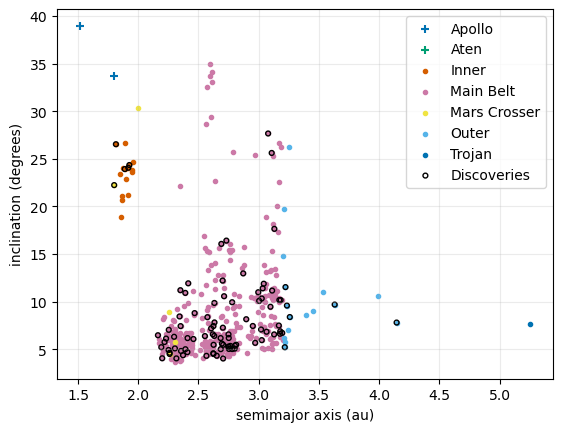

In [14]:
plt.scatter(Apollo["q"]/(1-Apollo["e"]), Apollo["incl"], marker='+', color=colors[0], label="Apollo")
plt.scatter(Aten["q"]/(1-Aten["e"]), Aten["incl"], marker='+', color=colors[1], label="Aten")
plt.scatter(Inner["q"]/(1-Inner["e"]), Inner["incl"], marker='.', color=colors[2], label="Inner")
plt.scatter(MainBelt["q"]/(1-MainBelt["e"]), MainBelt["incl"], marker='.', color=colors[3], label="Main Belt")
plt.scatter(MarsX["q"]/(1-MarsX["e"]), MarsX["incl"], marker='.', color=colors[4], label="Mars Crosser")
plt.scatter(Outer["q"]/(1-Outer["e"]), Outer["incl"], marker='.', color=colors[5], label="Outer")
plt.scatter(Trojan["q"]/(1-Trojan["e"]), Trojan["incl"], marker='.', color=colors[0], label="Trojan")

plt.scatter(discoveries["q"]/(1-discoveries["e"]), discoveries["incl"],marker='o', facecolors='none', edgecolors='k', s=12, label="Discoveries")

plt.xlabel("semimajor axis (au)")
plt.ylabel("inclination (degrees)")
plt.grid(alpha=.25)
plt.legend()

 > **Figure 1:** Semimajor axes and inclinations of the 431 DP1 Solar System objects with the colors distinguishing each orbital class.

Make a similar scatterplot of the *semi-major axis* (calculated from *q* and *e*) vs *eccentricity*, using the same color pallet defined earlier

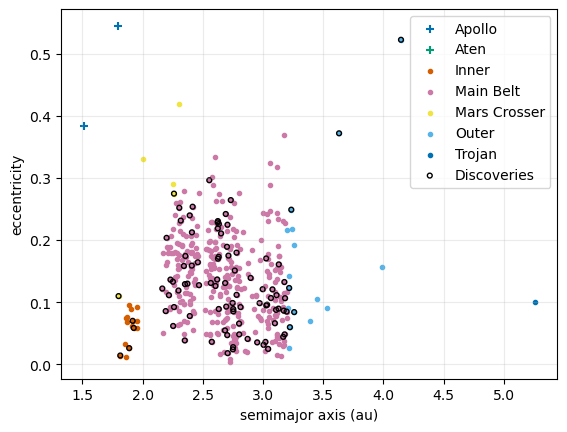

In [15]:
plt.scatter(Apollo["q"]/(1-Apollo["e"]), Apollo["e"], marker='+', color=colors[0], label="Apollo")
plt.scatter(Aten["q"]/(1-Aten["e"]), Aten["e"], marker='+', color=colors[1], label="Aten")
plt.scatter(Inner["q"]/(1-Inner["e"]), Inner["e"], marker='.', color=colors[2], label="Inner")
plt.scatter(MainBelt["q"]/(1-MainBelt["e"]), MainBelt["e"], marker='.', color=colors[3], label="Main Belt")
plt.scatter(MarsX["q"]/(1-MarsX["e"]), MarsX["e"], marker='.', color=colors[4], label="Mars Crosser")
plt.scatter(Outer["q"]/(1-Outer["e"]), Outer["e"], marker='.', color=colors[5], label="Outer")
plt.scatter(Trojan["q"]/(1-Trojan["e"]), Trojan["e"], marker='.', color=colors[0], label="Trojan")

plt.scatter(discoveries["q"]/(1-discoveries["e"]), discoveries["e"],marker='o', facecolors='none', edgecolors='k', s=12, label="Discoveries")

plt.xlabel("semimajor axis (au)")
plt.ylabel("eccentricity")
plt.grid(alpha=.25)
plt.legend()

For a more "pythonic" way of doing these plots take a look at the **RSP 308.2. Solar System orbit classifications tutorial**, where two interesting new things are done, they add a total number of the objects in each class to the legend, and make plots of *a* vs *e* and *a* vs *incl* for both detections and discoveries.


### Follow-up Activities
* Plot only the main belt and identify the *Kirkwood Gaps* https://en.wikipedia.org/wiki/Kirkwood_gap . You may wish to make use of a histogram for this as well.

Clean up.

In [16]:
del result, result_df, discoveries